<a href="https://colab.research.google.com/github/mithleshsingla/projects/blob/main/dl_assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Create a unique save path with timestamp
from datetime import datetime
save_path = f"/content/drive/MyDrive/fine_tuned_model_{datetime.now().strftime('%Y%m%d_%H%M%S')}"


Mounted at /content/drive


In [2]:

# Install necessary packages
!pip install -q transformers datasets accelerate bitsandbytes evaluate peft trl


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.4/336.4 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 23.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from tqdm import tqdm

In [4]:

# Check if GPU is available
print(f"Using GPU: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Available GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


Using GPU: True
GPU Name: Tesla T4
Available GPU memory: 15.83 GB


In [5]:

# 1. Model Selection (roughly 1B parameters, not fine-tuned)
model_id = "cerebras/Cerebras-GPT-1.3B"  # ~1.3B parameter model
print(f"Selected model: {model_id}")


Selected model: cerebras/Cerebras-GPT-1.3B


In [6]:

# 2. Data Preparation
# Load a dataset from Hugging Face for fine-tuning
dataset_name = "imdb"
dataset = load_dataset(dataset_name)
print(f"Dataset loaded: {dataset_name}")
print(f"Dataset structure: {dataset}")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

unsupervised-00000-of-00001.parquet:   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset loaded: imdb
Dataset structure: DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [7]:


# Take a small subset for faster training
train_dataset = dataset["train"].shuffle(seed=42).select(range(5000))
eval_dataset = dataset["test"].shuffle(seed=42).select(range(500))
print(f"Training data size: {len(train_dataset)}")
print(f"Evaluation data size: {len(eval_dataset)}")


Training data size: 5000
Evaluation data size: 500


In [8]:

# Initialize tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token
max_length = 512


config.json:   0%|          | 0.00/360 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

In [9]:

# Format dataset for causal language modeling
def format_text(example):
    return f"Review: {example['text']}\nSentiment: {'positive' if example['label'] == 1 else 'negative'}"

# Tokenize function
def tokenize_function(examples):
    texts = [format_text({"text": text, "label": label}) for text, label in zip(examples["text"], examples["label"])]
    return tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

In [10]:

# Process datasets
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=train_dataset.column_names
)

tokenized_eval = eval_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=eval_dataset.column_names
)


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [11]:

# Set up 4-bit quantization configuration
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

# Load model with quantization
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

pytorch_model.bin:   0%|          | 0.00/5.36G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/5.36G [00:00<?, ?B/s]

In [12]:
# Set up 4-bit quantization configuration
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

# Load model with quantization
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

# Print model structure to identify available modules
print("Model architecture preview:")
for name, _ in model.named_modules():
    print(name)
    # Limit output to first 30 modules to avoid overwhelming output
    if name.count('.') == 0 and name.count('_') == 0:
        print(f"  Top level module: {name}")

# Find linear layers for LoRA targeting
linear_modules = set()
for name, module in model.named_modules():
    if isinstance(module, torch.nn.Linear) and any(key_word in name for key_word in ['attention', 'mlp']):
        parent_name = '.'.join(name.split('.')[:-1])
        if parent_name:
            linear_modules.add(parent_name)
        print(f"Found Linear layer: {name}")

print(f"\nPotential LoRA target modules: {list(linear_modules)[:10]}")


Model architecture preview:

  Top level module: 
transformer
  Top level module: transformer
transformer.wte
transformer.wpe
transformer.drop
transformer.h
transformer.h.0
transformer.h.0.ln_1
transformer.h.0.attn
transformer.h.0.attn.c_attn
transformer.h.0.attn.c_proj
transformer.h.0.attn.attn_dropout
transformer.h.0.attn.resid_dropout
transformer.h.0.ln_2
transformer.h.0.mlp
transformer.h.0.mlp.c_fc
transformer.h.0.mlp.c_proj
transformer.h.0.mlp.act
transformer.h.0.mlp.dropout
transformer.h.1
transformer.h.1.ln_1
transformer.h.1.attn
transformer.h.1.attn.c_attn
transformer.h.1.attn.c_proj
transformer.h.1.attn.attn_dropout
transformer.h.1.attn.resid_dropout
transformer.h.1.ln_2
transformer.h.1.mlp
transformer.h.1.mlp.c_fc
transformer.h.1.mlp.c_proj
transformer.h.1.mlp.act
transformer.h.1.mlp.dropout
transformer.h.2
transformer.h.2.ln_1
transformer.h.2.attn
transformer.h.2.attn.c_attn
transformer.h.2.attn.c_proj
transformer.h.2.attn.attn_dropout
transformer.h.2.attn.resid_dropout
tran

In [13]:
# Configure LoRA
lora_config = LoraConfig(
    r=16,               # Rank
    lora_alpha=32,      # Alpha scaling
    target_modules=["attn.c_attn", "attn.c_proj", "mlp.c_fc", "mlp.c_proj"],  # Target the key linear layers
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

In [24]:

# 3. Fine-Tuning
# Set up training arguments
training_args = TrainingArguments(
    output_dir="./fine_tuned_model",
    label_names=["labels"],
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=16,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    logging_steps=10,
    learning_rate=5e-5,
    weight_decay=0.001,
    fp16=True,
    report_to="none",
    push_to_hub=False,
)



/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [25]:
# Configure LoRA with correct module names
lora_config = LoraConfig(
    r=16,               # Rank
    lora_alpha=32,      # Alpha scaling
    target_modules=["c_attn", "c_proj", "c_fc"],  # Use just the module names without full paths
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

In [26]:
# Load model with quantization
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

# Prepare model for training BEFORE adding LoRA adapters
model = prepare_model_for_kbit_training(model)

# Add LoRA adapters
model = get_peft_model(model, lora_config)

# Check trainable parameters to confirm LoRA is attached
trainable_params = model.print_trainable_parameters()
print(f"Trainable parameters: {trainable_params}")

trainable params: 12,582,912 || all params: 1,328,306,176 || trainable%: 0.9473
Trainable parameters: None


In [27]:
# After getting the PEFT model
print("Model type:", type(model))
print("Is PEFT model:", hasattr(model, "peft_config"))

# Check if any parameters have requires_grad=True
has_trainable = False
for name, param in model.named_parameters():
    if param.requires_grad:
        has_trainable = True
        print(f"Found trainable parameter: {name}")
        break

if not has_trainable:
    print("WARNING: No trainable parameters found!")

Model type: <class 'peft.peft_model.PeftModelForCausalLM'>
Is PEFT model: True
Found trainable parameter: base_model.model.transformer.h.0.attn.c_attn.lora_A.default.weight


In [28]:
from transformers import DataCollatorForLanguageModeling

# Create Trainer
from transformers import Trainer

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

In [29]:



# Then run training
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    data_collator=data_collator,
)

# Start training
print("Starting training...")
trainer.train()

# Explicitly save the final model
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)
print(f"Model permanently saved to Google Drive: {save_path}")


Starting training...


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch,Training Loss,Validation Loss
0,3.395500,3.319477
1,3.309400,3.302297


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Model permanently saved to Google Drive: /content/drive/MyDrive/fine_tuned_model_20250405_065614


In [30]:

# Save the fine-tuned model
trainer.save_model("./fine_tuned_model_final")
print("Model saved!")

Model saved!


In [31]:

# 4. Evaluation
# 4.1 Quantitative Evaluation

# Function to calculate perplexity
def calculate_perplexity(model, eval_dataset):
    model.eval()
    total_loss = 0
    total_length = 0

    with torch.no_grad():
        for i in tqdm(range(0, len(eval_dataset), 8), desc="Calculating perplexity"):
            batch = eval_dataset[i:i+8]
            input_ids = torch.tensor(batch["input_ids"]).cuda()
            attention_mask = torch.tensor(batch["attention_mask"]).cuda()

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=input_ids)
            loss = outputs.loss.item()

            batch_length = attention_mask.sum().item()
            total_loss += loss * batch_length
            total_length += batch_length

    perplexity = np.exp(total_loss / total_length)
    return perplexity


In [32]:

# Load the original model for comparison
original_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

print("Calculating perplexity for the original model...")
original_perplexity = calculate_perplexity(original_model, tokenized_eval)
print(f"Original model perplexity: {original_perplexity:.2f}")

print("Calculating perplexity for the fine-tuned model...")
fine_tuned_perplexity = calculate_perplexity(model, tokenized_eval)
print(f"Fine-tuned model perplexity: {fine_tuned_perplexity:.2f}")

# Plot perplexity comparison
plt.bar(['Original Model', 'Fine-tuned Model'], [original_perplexity, fine_tuned_perplexity])
plt.title('Perplexity Comparison')
plt.ylabel('Perplexity (lower is better)')
plt.savefig('perplexity_comparison.png')
plt.close()

Calculating perplexity for the original model...


Calculating perplexity: 100%|██████████| 63/63 [00:45<00:00,  1.38it/s]


Original model perplexity: 192.67
Calculating perplexity for the fine-tuned model...


Calculating perplexity: 100%|██████████| 63/63 [01:06<00:00,  1.06s/it]


Fine-tuned model perplexity: 215.33


In [44]:
trainer.state.log_history


[{'loss': 3.3955,
  'grad_norm': 0.13782158493995667,
  'learning_rate': 3.6842105263157895e-05,
  'epoch': 0.5111821086261981,
  'step': 10},
 {'eval_loss': 3.31947660446167,
  'eval_runtime': 63.5547,
  'eval_samples_per_second': 7.867,
  'eval_steps_per_second': 0.504,
  'epoch': 0.9712460063897763,
  'step': 19},
 {'loss': 3.6582,
  'grad_norm': 0.2531411051750183,
  'learning_rate': 2.368421052631579e-05,
  'epoch': 1.0511182108626198,
  'step': 20},
 {'loss': 3.3094,
  'grad_norm': 0.09788001328706741,
  'learning_rate': 1.0526315789473684e-05,
  'epoch': 1.5623003194888179,
  'step': 30},
 {'eval_loss': 3.3022971153259277,
  'eval_runtime': 63.9534,
  'eval_samples_per_second': 7.818,
  'eval_steps_per_second': 0.5,
  'epoch': 1.9712460063897763,
  'step': 38},
 {'train_runtime': 3889.8102,
  'train_samples_per_second': 2.571,
  'train_steps_per_second': 0.01,
  'total_flos': 3.697460626273075e+16,
  'train_loss': 3.421191416288677,
  'epoch': 1.9712460063897763,
  'step': 38}]

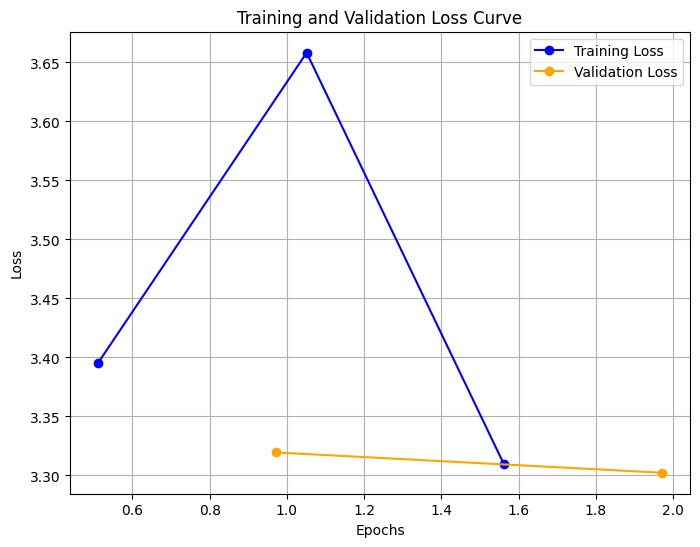

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert log history to a DataFrame
log_history = pd.DataFrame(trainer.state.log_history)

# Filter training and validation losses
training_loss = log_history[log_history['loss'].notnull()][['epoch', 'loss']]
validation_loss = log_history[log_history['eval_loss'].notnull()][['epoch', 'eval_loss']]

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(training_loss['epoch'], training_loss['loss'], label='Training Loss', marker='o', color='blue')
plt.plot(validation_loss['epoch'], validation_loss['eval_loss'], label='Validation Loss', marker='o', color='orange')
plt.title('Training and Validation Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [34]:
import numpy as np
import pandas as pd
import torch

def generate_samples(model, tokenizer, dataset, num_samples=10, max_length=100):
    model.eval()
    samples = []

    # Select random examples
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    for idx in indices:
        # Convert numpy.int64 to Python int
        idx = int(idx)
        example = dataset[idx]
        prompt = example["text"][:100] + "..."  # Use the start of the text as a prompt

        # Format the prompt
        formatted_prompt = f"Review: {prompt}\nSentiment:"

        # Tokenize the prompt
        inputs = tokenizer(formatted_prompt, return_tensors="pt").to("cuda")

        # Generate output
        with torch.no_grad():
            output_ids = model.generate(
                inputs["input_ids"],
                max_length=max_length,
                num_return_sequences=1,
                temperature=0.7,
            )

        generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)

        # Extract only the generated part (after the prompt)
        generated_part = generated_text[len(formatted_prompt):]

        samples.append({
            "prompt": formatted_prompt,
            "generated": generated_part.strip(),
            "original_sentiment": "positive" if dataset[idx]["label"] == 1 else "negative"
        })

    return samples

In [35]:

print("Generating samples from the original model...")
original_samples = generate_samples(original_model, tokenizer, eval_dataset)

print("Generating samples from the fine-tuned model...")
fine_tuned_samples = generate_samples(model, tokenizer, eval_dataset)


/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generating samples from the original model...


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generati

Generating samples from the fine-tuned model...


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generati

In [36]:

# Create a dataframe for easy comparison
comparison_df = pd.DataFrame({
    "Prompt": [s["prompt"] for s in original_samples],
    "Original Model Output": [s["generated"] for s in original_samples],
    "Fine-tuned Model Output": [s["generated"] for s in fine_tuned_samples],
    "Ground Truth": [s["original_sentiment"] for s in original_samples]
})


In [37]:

# Save the comparison to a CSV file
comparison_df.to_csv("model_output_comparison.csv", index=False)
print("Sample outputs saved to model_output_comparison.csv")


Sample outputs saved to model_output_comparison.csv


In [38]:

# Create a qualitative evaluation template
eval_template = pd.DataFrame({
    "Sample #": range(1, 11),
    "Original Model Score (0-5)": [None] * 10,
    "Fine-tuned Model Score (0-5)": [None] * 10,
    "Comments": [None] * 10
})

eval_template.to_csv("qualitative_evaluation_template.csv", index=False)
print("Evaluation template saved to qualitative_evaluation_template.csv")


Evaluation template saved to qualitative_evaluation_template.csv


In [39]:

print("\nFine-tuning project completed successfully!")
print("\nSummary:")
print(f"- Used model: {model_id}")
print(f"- Dataset: {dataset_name} (Training: {len(train_dataset)} samples, Evaluation: {len(eval_dataset)} samples)")
print(f"- Perplexity improvement: {original_perplexity:.2f} -> {fine_tuned_perplexity:.2f}")
print("- Generated 10 sample outputs from both models for manual evaluation")
print("- Please use the qualitative_evaluation_template.csv file to score each model's outputs")


Fine-tuning project completed successfully!

Summary:
- Used model: cerebras/Cerebras-GPT-1.3B
- Dataset: imdb (Training: 5000 samples, Evaluation: 500 samples)
- Perplexity improvement: 192.67 -> 215.33
- Generated 10 sample outputs from both models for manual evaluation
- Please use the qualitative_evaluation_template.csv file to score each model's outputs


In [40]:
df=pd.read_csv("model_output_comparison.csv")

In [41]:
df

,Prompt,Original Model Output,Fine-tuned Model Output,Ground Truth
0,Review: An intense thriller about a mute movie...,"The film is a bit of a letdown, but it's a goo...",positive\nOverall: positive\nSubtitles: Englis...,positive
1,"Review: ""Where to begin, where to begin . . ?(...","""I'm not sure I'm ready for this. I'm not sure...",negative\nOverall: negative\nSubtitles: Englis...,positive
2,Review: Found this movie in a rental store. Ne...,I liked the movie. I liked the acting. I liked...,positive\nOverall: positive\nSubtitles: Englis...,positive
3,"Review: A Great show.<br /><br />First, to the...",I'm not a fan of the show. I don't like the sh...,positive.\nOverall: a very good film.\nSubtitl...,positive
4,Review: some would argue this is better mainly...,"I think it is a good film, but it is not a goo...",positive\nOverall: positive\n\nThis is a very ...,negative
5,Review: I thought this was a very daring repre...,I thought this was a very daring representatio...,positive\nOverall: positive\nSubtitles: Englis...,positive
6,Review: Oh noes one of these attack of the Jap...,I'm not sure if it's a good thing or a bad thi...,negative\nOverall: negative\nSubtitles: Englis...,negative
7,Review: I had the pleasure of seeing Saltimban...,I was very impressed with the show. The show w...,negative\nOverall: negative\nSubtitles: Englis...,positive
8,Review: Gritty drama? Emotionally powerful? Bl...,The BBC has lost out big time to masterful pro...,positive\nOverall: positive\n\nSentiment: posi...,negative
9,Review: I knew I was in for a LONG 90 minutes ...,I was in for a LONG 90 minutes when the openin...,positive\nOverall: positive\nOverall Score: 3....,negative


In [56]:
eval_template = pd.DataFrame({
       "Sample #": range(1, 11),
       "Original Model Score (0-5)": [''] * 10,  # Use empty strings
       "Fine-tuned Model Score (0-5)": [''] * 10, # Use empty strings
                          # Use empty strings
   })

In [57]:
eval_template.loc[0, "Original Model Score (0-5)"] = 3  # Set score for Sample 1
eval_template.loc[0, "Fine-tuned Model Score (0-5)"] = 4   # Set score for Sample 1

In [60]:
for i in range(10):
         original_score = input(f"Enter Original Model Score (0-5) for Sample {i+1}: ")
         fine_tuned_score = input(f"Enter Fine-tuned Model Score (0-5) for Sample {i+1}: ")


         eval_template.loc[i, "Original Model Score (0-5)"] = original_score
         eval_template.loc[i, "Fine-tuned Model Score (0-5)"] = fine_tuned_score


Enter Original Model Score (0-5) for Sample 1: 4
Enter Fine-tuned Model Score (0-5) for Sample 1: 4
Enter Original Model Score (0-5) for Sample 2: 5
Enter Fine-tuned Model Score (0-5) for Sample 2: 4.5
Enter Original Model Score (0-5) for Sample 3: 5
Enter Fine-tuned Model Score (0-5) for Sample 3: 5
Enter Original Model Score (0-5) for Sample 4: 4
Enter Fine-tuned Model Score (0-5) for Sample 4: 4.5
Enter Original Model Score (0-5) for Sample 5: 5
Enter Fine-tuned Model Score (0-5) for Sample 5: 4.5
Enter Original Model Score (0-5) for Sample 6: 4
Enter Fine-tuned Model Score (0-5) for Sample 6: 4.5
Enter Original Model Score (0-5) for Sample 7: 5
Enter Fine-tuned Model Score (0-5) for Sample 7: 5
Enter Original Model Score (0-5) for Sample 8: 4
Enter Fine-tuned Model Score (0-5) for Sample 8: 5
Enter Original Model Score (0-5) for Sample 9: 4.5
Enter Fine-tuned Model Score (0-5) for Sample 9: 4,5
Enter Original Model Score (0-5) for Sample 10: 5
Enter Fine-tuned Model Score (0-5) for

In [62]:
eval_template.to_csv("qualitative_evaluation_template.csv", index=False)
print("Evaluation template saved to qualitative_evaluation_template.csv")

Evaluation template saved to qualitative_evaluation_template.csv


In [64]:
evaluation_qualitative=pd.read_csv("qualitative_evaluation_template.csv")

In [65]:
evaluation_qualitative

,Sample #,Original Model Score (0-5),Fine-tuned Model Score (0-5)
0,1,4.0,4
1,2,5.0,4.5
2,3,5.0,5
3,4,4.0,4.5
4,5,5.0,4.5
5,6,4.0,4.5
6,7,5.0,5
7,8,4.0,5
8,9,4.5,"4,5"
9,10,5.0,4


In [66]:
from google.colab import files
files.download('qualitative_evaluation_template.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>